In [1]:
import os
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

## Dataset Visualization

In [4]:
source_folder = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_live_face_dataset/live"
folder_swapped = {"mobilefaceswap":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/mobilefaceswap",
                  "e4s":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/e4s_20251103",
                  "reswapper":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/reswapper",
                  "blendface":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/blendface",
                  "uniface":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/uniface"}

In [5]:
list_source_images = os.listdir(source_folder)
list_img_files = os.listdir(folder_swapped["mobilefaceswap"])

In [6]:
swapped_img_name = list_img_files[0]
source_img_name, target_img_name = swapped_img_name.split('.jpg')[0].split('_to_')
swapped_img_path = os.path.join(folder_swapped["mobilefaceswap"],swapped_img_name)
source_img_path = os.path.join(source_folder,[s for s in list_source_images if s.startswith(source_img_name)][0])
target_img_path = os.path.join(source_folder,[s for s in list_source_images if s.startswith(target_img_name)][0])

In [7]:
source_img_path

'/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_live_face_dataset/live/38368_verify_67dfb808-1e6c-47d6-b5ca-d23ae43dea20_11e03acf-3c0b-4e3d-96b1-6333e424a80f_original.jpg.jpg'

In [8]:
list(swapped_img_name.split('.jpg')[0].split('_to_'))

['38368_verify_67dfb808-1e6c-47d6-b5ca-d23ae43dea20_11e03acf-3c0b-4e3d-96b1-6333e424a80f_original',
 '169604_verify_90919c30-5031-4b92-a0cd-bb8e565bd660_4db71cc5-dbf6-4b36-9391-c00364c84101_original']

In [9]:
def plot_triplet(source_img_path, target_img_path, swapped_img_path):
    fig, ax = plt.subplots(1,3)
    img_now = cv2.cvtColor(cv2.imread(source_img_path),cv2.COLOR_BGR2RGB); ax[0].imshow(img_now);ax[0].axis("off");ax[0].set_title("Source")
    img_now = cv2.cvtColor(cv2.imread(target_img_path),cv2.COLOR_BGR2RGB); ax[1].imshow(img_now);ax[1].axis("off");ax[1].set_title("Target")
    img_now = cv2.cvtColor(cv2.imread(swapped_img_path),cv2.COLOR_BGR2RGB); ax[2].imshow(img_now);ax[2].axis("off");ax[2].set_title("Swapped")

    return fig,ax

def plot_multiple(image_paths, image_labels):
    fig, ax = plt.subplots(1,len(image_paths), figsize=(2*len(image_paths), 4))

    for id_image, image_path in enumerate(image_paths):
        img_now = cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB) 
        ax[id_image].imshow(img_now)
        ax[id_image].axis("off")
        ax[id_image].set_title(image_labels[id_image])
        
    return fig,ax

In [23]:
swapped_img_name = list_img_files[20]
source_img_name, target_img_name = swapped_img_name.split('.jpg')[0].split('_to_')
mobilefaceswap_img_path = os.path.join(folder_swapped["mobilefaceswap"],swapped_img_name)
#e4s_img_path = os.path.join(folder_swapped["e4s"],swapped_img_name)
e4s_img_path = os.path.join(folder_swapped["e4s"],"swap_"+swapped_img_name.split(".jpg")[0]+".png")
reswapper_img_path = os.path.join(folder_swapped["reswapper"],swapped_img_name)
uniface_img_path = os.path.join(folder_swapped["uniface"],swapped_img_name)
blendface_img_path = os.path.join(folder_swapped["blendface"],swapped_img_name)
source_img_path = os.path.join(source_folder,[s for s in list_source_images if s.startswith(source_img_name)][0])
target_img_path = os.path.join(source_folder,[s for s in list_source_images if s.startswith(target_img_name)][0])

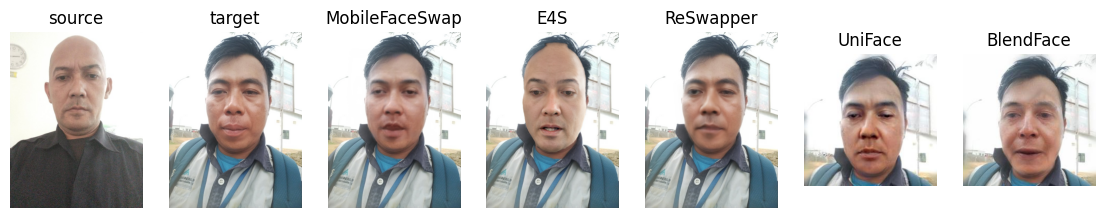

In [24]:
#reswapper_img_path
#fig,ax = plot_triplet(source_img_path, target_img_path, swapped_img_path)
fig,ax = plot_multiple([source_img_path, target_img_path, mobilefaceswap_img_path,e4s_img_path,reswapper_img_path,uniface_img_path,blendface_img_path],\
                       ["source","target","MobileFaceSwap","E4S","ReSwapper","UniFace","BlendFace"])

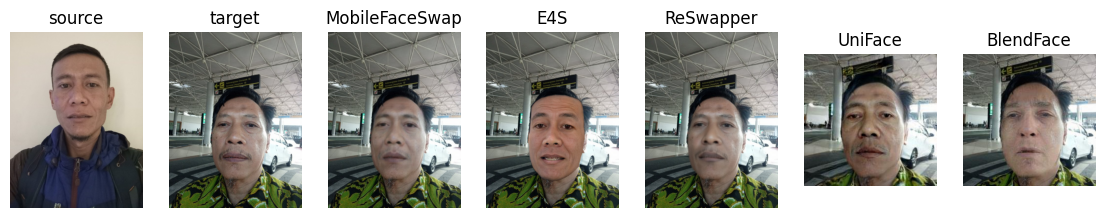

In [38]:
os.listdir(source_folder)[:20]

['76915_verify_e632371d-b106-46a3-81ac-f0692bbbc561_62a11a49-42c5-4633-999a-404bec1504cb_original.jpg.jpg',
 '41559_verify_7ab6e827-1b82-4236-b206-a37d3e99a70c_85e9417b-d14b-4902-bb1d-45a21bd55d8c_original.jpg.jpg',
 '221889_verify_d50bd37d-ef1a-465d-8a53-556d3f933f95_54f7a9ad-a687-4597-bcdc-426a16d3dfec_original.jpg.jpg',
 '7195_verify_b572438e-5728-4f57-9cb9-4db4cd4e6de1_395ff453-16b2-4a5e-9459-bb016745fb63_original.jpg.jpg',
 '109478_verify_953a2c87-e6f5-4896-8cc7-5f0e13f13011_d4b04932-fb80-4ac5-a52f-0040dc753607_original.jpg.jpg',
 '204025_verify_74f1de5e-9c9b-4055-9a80-f862cfa155d2_b37e3943-e7a9-4a41-b398-baa9589a1a68_original.jpg.jpg',
 '123148_compare_1_31d716d1-0c73-4c4a-b4af-e32955f5d500_9b7a295d-a9f6-40d1-b69a-c3329a5b34b6_original.jpg.jpg',
 '218451_verify_40240113-cb29-47b2-ab09-a27b87c09338_f631657f-33b9-47af-af10-1d23bc9af5f0_original.jpg.jpg',
 '62501_verify_1fc427cb-007f-4bd7-b7b5-368e9f0dd65e_91501e7c-3aec-4417-8bc7-f7eeaeadf3b1_original.jpg.jpg',
 '49170_verify_fd5f2c